In [1]:
!pip install protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

Successfully patched sklearn.utils.check_array for UMAP compatibility.


2025-11-19 06:34:24.960544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763534065.375112      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763534065.552380      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Data loaded: 40506 sentence pairs.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Generating Embeddings:   0%|          | 0/633 [00:00<?, ?it/s]


Generating S2 Embeddings...


Generating Embeddings:   0%|          | 0/633 [00:00<?, ?it/s]


Applying UMAP...


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisati

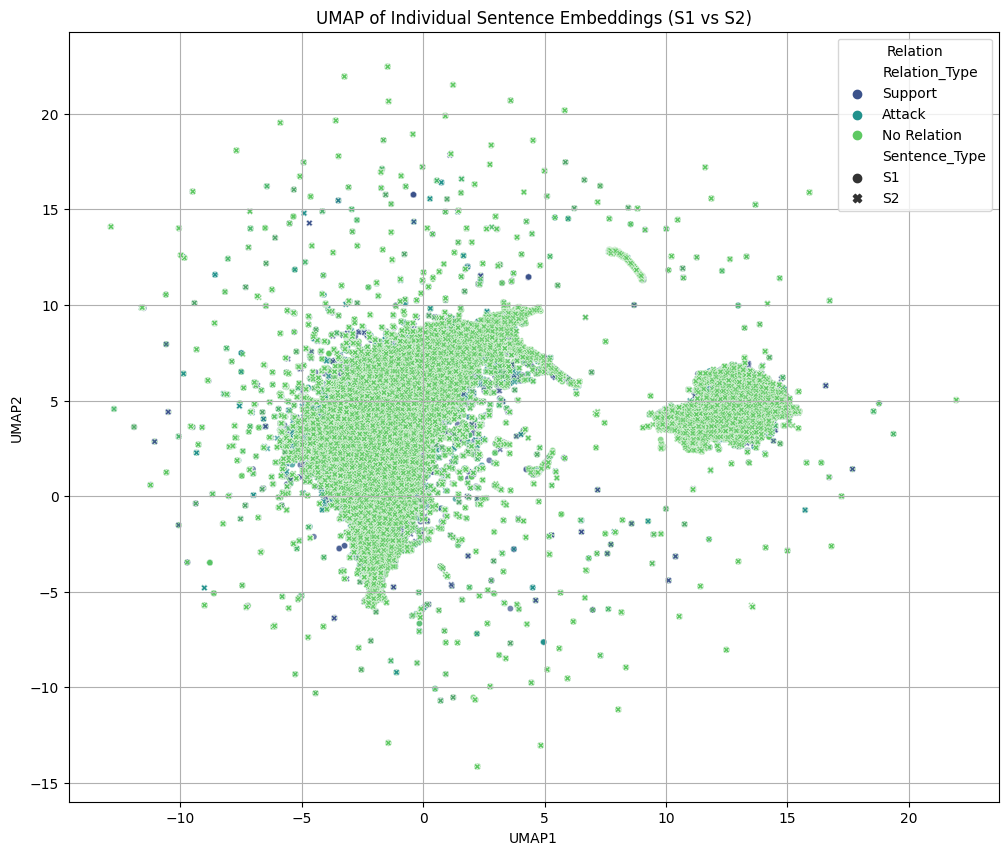

In [2]:
import os
import sys
import warnings

# --- 1. FIX FOR SKLEARN/UMAP VERSION CONFLICT ---
# Newer scikit-learn removed 'ensure_all_finite', but UMAP still uses it.
# We monkey-patch check_array to map the old argument to the new one.
try:
    import sklearn.utils.validation
    _original_check_array = sklearn.utils.validation.check_array

    def _patched_check_array(array, *args, **kwargs):
        # If the old argument is present, rename it to the new one
        if 'ensure_all_finite' in kwargs:
            kwargs['force_all_finite'] = kwargs.pop('ensure_all_finite')
        return _original_check_array(array, *args, **kwargs)

    # Apply the patch
    sklearn.utils.validation.check_array = _patched_check_array
    if hasattr(sklearn.utils, 'check_array'):
        sklearn.utils.check_array = _patched_check_array
    print("Successfully patched sklearn.utils.check_array for UMAP compatibility.")
except ImportError:
    print("Could not patch sklearn; ensure it is installed.")
# ------------------------------------------------

# Fix for some protobuf/tensorflow conflicts
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

# Import UMAP *after* the patch to ensure it picks up the fix
import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from dataclasses import dataclass

# --- 2. Configuration ---
@dataclass
class Config:
    MODEL_NAME: str = "nlpaueb/legal-bert-base-uncased"
    CHECKPOINT_PATH: str = "/kaggle/input/best-lbert-lrec/pytorch/default/1/best_model.pt" 
    POS_DATA_FILE: str = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE: str = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    MAX_LEN: int = 256
    BATCH_SIZE: int = 64
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    LABEL_MAP = {"SUPPORT": "Support", "ATTACK": "Attack", "NO_REL": "No Relation", "NO_REL\n": "No Relation"}

# --- 3. Data Loading ---
def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    # Robust parsing
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: Config):
    rows = []
    # Check files exist
    files_found = False
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if os.path.exists(fp):
            files_found = True
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    if parsed := parse_lrec_line(line):
                        rows.append(parsed)
        else:
            print(f"Warning: File not found {fp}")
    
    if not files_found:
        print("Error: No data files found. Please upload sentencePair.txt.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    if df.empty:
        return df
        
    df['label_str'] = df['label'].map(config.LABEL_MAP)
    df = df.dropna(subset=["sent1", "sent2", "label_str"]).reset_index(drop=True)
    return df

class SingleSentenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len):
        self.sentences, self.tokenizer, self.max_len = sentences, tokenizer, max_len

    def __len__(self): 
        return len(self.sentences)

    def __getitem__(self, idx):
        text = str(self.sentences[idx])
        encoded = self.tokenizer(
            text, 
            padding="max_length", 
            truncation=True, 
            max_length=self.max_len, 
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoded["input_ids"].squeeze(0), 
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }

# --- 4. Model Definition ---

class FineTunedEncoder(nn.Module):
    """A wrapper to load the encoder from the fine-tuned classifier checkpoint."""
    def __init__(self, model_name, checkpoint_path, device):
        super().__init__() 
        
        # Define internal dummy class to match saved checkpoint structure
        class DummyClassifier(nn.Module):
            def __init__(self, hf_model_name, num_labels, dropout_1, dropout_2):
                super(DummyClassifier, self).__init__()
                self.encoder = AutoModel.from_pretrained(hf_model_name, output_hidden_states=True) 
                self.dropout_1 = nn.Dropout(dropout_1)
                self.linear = nn.Linear(self.encoder.config.hidden_size, 512) 
                self.dropout_2 = nn.Dropout(dropout_2)
                self.relu = nn.ReLU()
                self.out = nn.Linear(512, num_labels)
            
            def forward(self, input_ids, attention_mask):
                output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
                return output.last_hidden_state[:, 0, :]

        dummy_config = {
            "hf_model_name": model_name,
            "num_labels": 3,
            "dropout_1": 0.1,
            "dropout_2": 0.4
        }
        
        print(f"Initializing model structure...")
        classifier = DummyClassifier(**dummy_config).to(device)
        
        if os.path.exists(checkpoint_path):
            print(f"Loading checkpoint from {checkpoint_path}...")
            try:
                state_dict = torch.load(checkpoint_path, map_location=device)
                
                # Handle nested keys if any
                best_fold_key = [k for k in state_dict.keys() if 'best_model_fold_' in k]
                
                if best_fold_key:
                    best_model_path = state_dict[best_fold_key[0]]
                    # Check if the path inside the checkpoint is valid (often not in Kaggle)
                    if os.path.exists(best_model_path):
                         classifier.load_state_dict(torch.load(best_model_path, map_location=device))
                    else:
                        print(f"Warning: Path in checkpoint {best_model_path} invalid. Trying to load state_dict directly if possible.")
                        # Sometimes state_dict holds the weights directly in other formats
                else:
                    classifier.load_state_dict(state_dict)
                print("Successfully loaded weights.")
            except Exception as e:
                print(f"Error loading weights: {e}. Using base LegalBERT.")
        else:
            print(f"Warning: Checkpoint not found at {checkpoint_path}. Using base weights.")
        
        self.model = classifier.encoder
        self.model.eval()

    def get_embeddings(self, data_loader):
        embeddings = []
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Generating Embeddings"):
                input_ids = batch["input_ids"].to(Config.DEVICE)
                attention_mask = batch["attention_mask"].to(Config.DEVICE)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)

        return np.vstack(embeddings)

def run_embedding_generation_and_plotting(df):
    if df.empty:
        print("No data loaded. Exiting.")
        return

    try:
        tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
    except Exception as e:
        print(f"Error loading tokenizer: {e}")
        return

    # Load model
    encoder_system = FineTunedEncoder(Config.MODEL_NAME, Config.CHECKPOINT_PATH, Config.DEVICE)

    # Prepare DataLoaders
    s1_dataset = SingleSentenceDataset(df['sent1'].tolist(), tokenizer, Config.MAX_LEN)
    s2_dataset = SingleSentenceDataset(df['sent2'].tolist(), tokenizer, Config.MAX_LEN)

    s1_dataloader = DataLoader(s1_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    s2_dataloader = DataLoader(s2_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

    # Generate Embeddings
    print("\nGenerating S1 Embeddings...")
    s1_embeddings = encoder_system.get_embeddings(s1_dataloader)
    
    print("\nGenerating S2 Embeddings...")
    s2_embeddings = encoder_system.get_embeddings(s2_dataloader)

    # Combine
    combined_embeddings = np.vstack([s1_embeddings, s2_embeddings])
    
    s1_labels = [f"S1 ({lbl})" for lbl in df['label_str'].tolist()]
    s2_labels = [f"S2 ({lbl})" for lbl in df['label_str'].tolist()]
    combined_labels = s1_labels + s2_labels
    base_labels = df['label_str'].tolist() * 2 
    
    umap_df = pd.DataFrame(combined_embeddings)
    umap_df['Sentence_Type'] = ['S1'] * len(s1_embeddings) + ['S2'] * len(s2_embeddings)
    umap_df['Relation_Type'] = base_labels

    print("\nApplying UMAP...")
    # Reduce dimensionality
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d = reducer.fit_transform(combined_embeddings)
    
    umap_df['UMAP1'] = embeddings_2d[:, 0]
    umap_df['UMAP2'] = embeddings_2d[:, 1]
    
    # Plot
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='UMAP1', y='UMAP2', hue='Relation_Type', style='Sentence_Type', 
        data=umap_df, palette='viridis', s=20, alpha=0.7
    )
    plt.title("UMAP of Individual Sentence Embeddings (S1 vs S2)")
    plt.legend(title="Relation")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    cfg = Config()
    df = load_full_data(cfg)
    print(f"Data loaded: {len(df)} sentence pairs.")
    run_embedding_generation_and_plotting(df)

import os
# Fix for some protobuf/tensorflow conflicts
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import re
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from dataclasses import dataclass

# --- 1. Configuration ---
@dataclass
class Config:
    MODEL_NAME: str = "nlpaueb/legal-bert-base-uncased"
    CHECKPOINT_PATH: str = "/kaggle/input/best-lbert-lrec/pytorch/default/1/best_model.pt" 
    POS_DATA_FILE: str = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE: str = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    MAX_LEN: int = 256
    BATCH_SIZE: int = 64
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    LABEL_MAP = {"SUPPORT": "Support", "ATTACK": "Attack", "NO_REL": "No Relation", "NO_REL\n": "No Relation"}

# --- 2. Data Loading ---
def parse_lrec_line(line: str):
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        sentpair_id = int(parts[0])
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: Config):
    rows = []
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                for line in f:
                    if parsed := parse_lrec_line(line):
                        rows.append(parsed)
        else:
            print(f"Warning: File not found {fp}")
    
    df = pd.DataFrame(rows)
    if df.empty:
        return df
        
    df['label_str'] = df['label'].map(config.LABEL_MAP)
    df = df.dropna(subset=["sent1", "sent2", "label_str"]).reset_index(drop=True)
    return df

class SingleSentenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len):
        self.sentences, self.tokenizer, self.max_len = sentences, tokenizer, max_len

    def __len__(self): 
        return len(self.sentences)

    def __getitem__(self, idx):
        text = str(self.sentences[idx])
        encoded = self.tokenizer(
            text, 
            padding="max_length", 
            truncation=True, 
            max_length=self.max_len, 
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoded["input_ids"].squeeze(0), 
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }

# --- 3. Model Definition ---

class FineTunedEncoder(nn.Module):
    """A wrapper to load the encoder from the fine-tuned classifier checkpoint."""
    def __init__(self, model_name, checkpoint_path, device):
        super().__init__() # Initialize parent nn.Module
        
        # Define internal dummy class to match saved checkpoint structure
        class DummyClassifier(nn.Module):
            def __init__(self, hf_model_name, num_labels, dropout_1, dropout_2):
                super(DummyClassifier, self).__init__()
                self.encoder = AutoModel.from_pretrained(hf_model_name, output_hidden_states=True) 
                self.dropout_1 = nn.Dropout(dropout_1)
                self.linear = nn.Linear(self.encoder.config.hidden_size, 512) 
                self.dropout_2 = nn.Dropout(dropout_2)
                self.relu = nn.ReLU()
                self.out = nn.Linear(512, num_labels)
            
            def forward(self, input_ids, attention_mask):
                output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
                return output.last_hidden_state[:, 0, :]

        dummy_config = {
            "hf_model_name": model_name,
            "num_labels": 3,
            "dropout_1": 0.1,
            "dropout_2": 0.4
        }
        
        print(f"Initializing model structure...")
        classifier = DummyClassifier(**dummy_config).to(device)
        
        if os.path.exists(checkpoint_path):
            print(f"Loading checkpoint from {checkpoint_path}...")
            state_dict = torch.load(checkpoint_path, map_location=device)
            
            # Handle case where checkpoint saves 'best_model_fold_X' keys
            best_fold_key = [k for k in state_dict.keys() if 'best_model_fold_' in k]
            
            if best_fold_key:
                best_model_path = state_dict[best_fold_key[0]]
                if os.path.exists(best_model_path):
                    classifier.load_state_dict(torch.load(best_model_path, map_location=device))
                    print("Loaded best fold model.")
                else:
                    print(f"Warning: Best model path inside checkpoint not found: {best_model_path}")
            else:
                # Try loading state dict directly
                try:
                    classifier.load_state_dict(state_dict)
                    print("Loaded state dict directly.")
                except Exception as e:
                    print(f"Could not load state dict directly: {e}")
        else:
            print(f"Warning: Checkpoint not found at {checkpoint_path}. Using base weights.")
        
        self.model = classifier.encoder
        self.model.eval()

    def get_embeddings(self, data_loader):
        embeddings = []
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Generating Embeddings"):
                input_ids = batch["input_ids"].to(Config.DEVICE)
                attention_mask = batch["attention_mask"].to(Config.DEVICE)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)

        return np.vstack(embeddings)

def run_embedding_generation_and_plotting(df):
    if df.empty:
        print("No data loaded. Exiting.")
        return

    tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
    
    # Load model ONCE
    encoder_system = FineTunedEncoder(Config.MODEL_NAME, Config.CHECKPOINT_PATH, Config.DEVICE)

    # Prepare DataLoaders
    s1_dataset = SingleSentenceDataset(df['sent1'].tolist(), tokenizer, Config.MAX_LEN)
    s2_dataset = SingleSentenceDataset(df['sent2'].tolist(), tokenizer, Config.MAX_LEN)

    s1_dataloader = DataLoader(s1_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    s2_dataloader = DataLoader(s2_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

    # Generate Embeddings using the SAME encoder instance
    print("\nGenerating S1 Embeddings...")
    s1_embeddings = encoder_system.get_embeddings(s1_dataloader)
    
    print("\nGenerating S2 Embeddings...")
    s2_embeddings = encoder_system.get_embeddings(s2_dataloader)

    # Combine and Plot
    combined_embeddings = np.vstack([s1_embeddings, s2_embeddings])
    
    s1_labels = [f"S1 ({lbl})" for lbl in df['label_str'].tolist()]
    s2_labels = [f"S2 ({lbl})" for lbl in df['label_str'].tolist()]
    combined_labels = s1_labels + s2_labels
    base_labels = df['label_str'].tolist() * 2 
    
    umap_df = pd.DataFrame(combined_embeddings)
    umap_df['Sentence_Type'] = ['S1'] * len(s1_embeddings) + ['S2'] * len(s2_embeddings)
    umap_df['Relation_Type'] = base_labels
    umap_df['Full_Label'] = combined_labels

    print("\nApplying UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine', random_state=42)
    embeddings_2d = reducer.fit_transform(combined_embeddings)
    
    umap_df['UMAP1'] = embeddings_2d[:, 0]
    umap_df['UMAP2'] = embeddings_2d[:, 1]
    
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='UMAP1', y='UMAP2', hue='Relation_Type', style='Sentence_Type', 
        data=umap_df, palette='viridis', s=20, alpha=0.7
    )
    plt.title("UMAP of Individual Sentence Embeddings (S1 vs S2)")
    plt.legend(title="Relation")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    cfg = Config()
    df = load_full_data(cfg)
    print(f"Data loaded: {len(df)} sentence pairs.")
    run_embedding_generation_and_plotting(df)